<a href="https://colab.research.google.com/github/MarianaCelisBougard/Taller_NNA_Grupo4/blob/main/Modeling/Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""
==============================================================================
CRISP-DM FASE 4: MODELING - ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES (MCA)
Proyecto: Caracterización de NNA en Programas de Intervención
Notebook 3 de 4 - Análisis Multivariado
==============================================================================
"""

# ==============================================================================
# 1. CONFIGURACIÓN INICIAL
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

# Instalación de librerías específicas para MCA
!pip install prince -q
!pip install factor-analyzer -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Librerías para MCA y Análisis Estadístico
import prince
import scipy.stats as stats


# Librerías para CLUSTERING (KMeans, Silhouette)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Configuración visual
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("CRISP-DM FASE 4: MODELING - ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES")
print("Proyecto: Caracterización de NNA en Trabajo Infantil")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRISP-DM FASE 4: MODELING - ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES
Proyecto: Caracterización de NNA en Trabajo Infantil
Fecha de ejecución: 2025-10-16 17:48:30


In [ ]:
# ==============================================================================
# 2. CARGA DE DATOS PREPARADOS
# ==============================================================================

ruta_datos = '/content/drive/MyDrive/Python/Proyecto NNA/datos_mca_preparados.csv'

print("\n📂 Cargando datos preparados...")
datos_mca = pd.read_csv(ruta_datos)

print(f"✅ Datos cargados exitosamente")
print(f"   - Dataset: {datos_mca.shape[0]:,} registros × {datos_mca.shape[1]} variables")
print(f"   - Variables categóricas: {datos_mca.shape[1]}")

# Verificar estructura
print(f"\n📋 Variables disponibles:")
for i, col in enumerate(datos_mca.columns, 1):
    n_cat = datos_mca[col].nunique()
    print(f"   {i:2d}. {col:<50} ({n_cat:3d} categorías)")


📂 Cargando datos preparados...
✅ Datos cargados exitosamente
   - Dataset: 56,473 registros × 21 variables
   - Variables categóricas: 21

📋 Variables disponibles:
    1. SEXO                                               (  4 categorías)
    2. ESTRATO                                            (  5 categorías)
    3. Localidad_fic                                      ( 17 categorías)
    4. TIPO INTERVENCIÓN                                  (  5 categorías)
    5. NACIONALIDAD                                       (  4 categorías)
    6. ESTADO CIVIL                                       (  3 categorías)
    7. ETNIA                                              (  2 categorías)
    8. POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN               (  3 categorías)
    9. OCUPACIÓN                                          (  6 categorías)
   10. CATEGORÍAS DE LA DISCAPACIDAD                      (  2 categorías)
   11. VÍNCULO CON EL JEFE DE HOGAR                       (  4 categorías)
   12. ZON


🔍 ANÁLISIS EXPLORATORIO PRE-MCA

📊 Resumen de cardinalidad:
                                                       Variable  N_Categorias  N_Registros    Ratio
                                                  Localidad_fic            17        56473 0.000301
                                                      OCUPACIÓN             6        56473 0.000106
                                              TIPO INTERVENCIÓN             5        56473 0.000089
                                              BARRIO PRIORIZADO             5        56473 0.000089
                                                        ESTRATO             5        56473 0.000089
                                                   UPZ_DENSIDAD             5        56473 0.000089
                   ¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?             5        56473 0.000089
                                                     EDAD_GRUPO             5        56473 0.000089
                       NNA DESVINCULADO

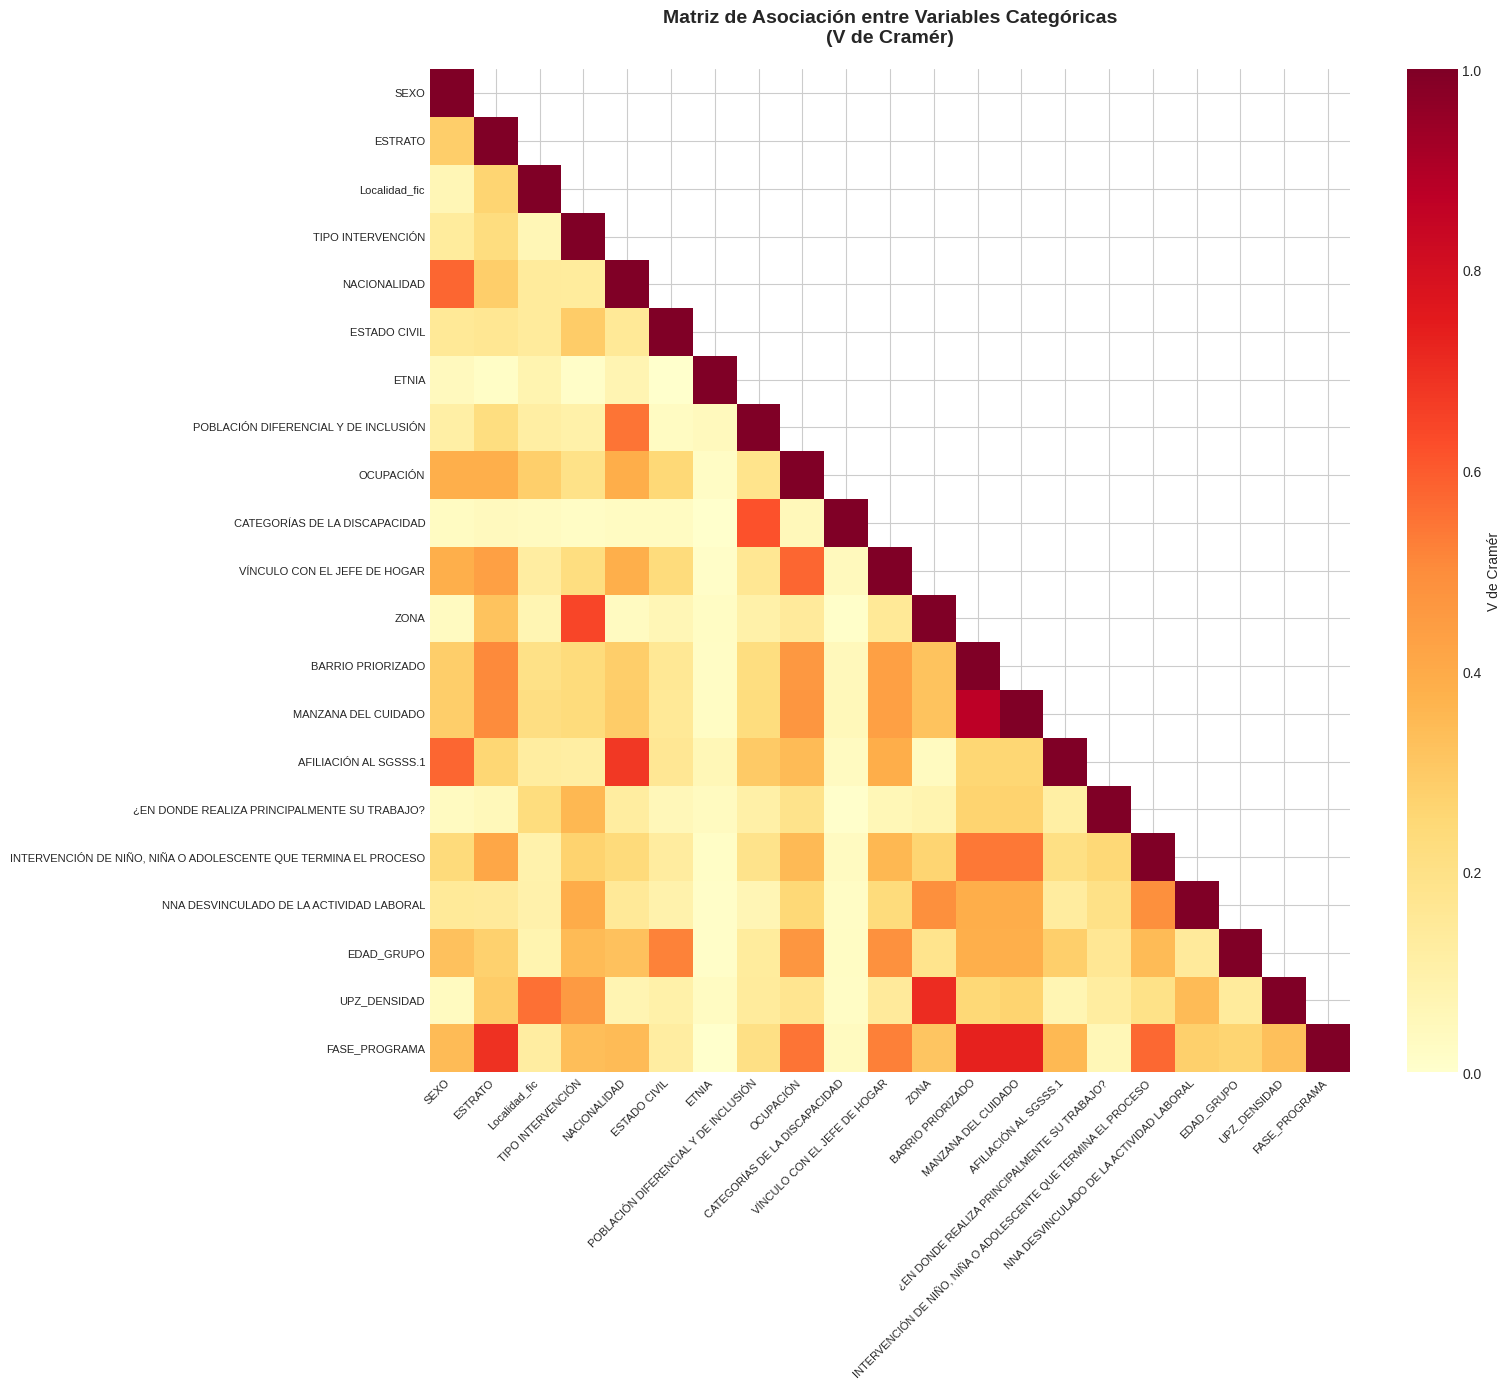


🔗 Asociaciones más fuertes (V de Cramér > 0.5):
                                                     Variable_1                                                      Variable_2  V_Cramer
                                              BARRIO PRIORIZADO                                             MANZANA DEL CUIDADO  0.873981
                                              BARRIO PRIORIZADO                                                   FASE_PROGRAMA  0.731834
                                            MANZANA DEL CUIDADO                                                   FASE_PROGRAMA  0.731774
                                                           ZONA                                                    UPZ_DENSIDAD  0.703514
                                                        ESTRATO                                                   FASE_PROGRAMA  0.693757
                                                   NACIONALIDAD                                           AFILIACIÓN AL SGS

In [ ]:

# ==============================================================================
# 3. ANÁLISIS EXPLORATORIO PRE-MCA
# ==============================================================================

print("\n" + "=" * 80)
print("🔍 ANÁLISIS EXPLORATORIO PRE-MCA")
print("=" * 80)

# 3.1 Resumen estadístico
print("\n📊 Resumen de cardinalidad:")
cardinalidad = pd.DataFrame({
    'Variable': datos_mca.columns,
    'N_Categorias': [datos_mca[col].nunique() for col in datos_mca.columns],
    'N_Registros': len(datos_mca),
    'Ratio': [datos_mca[col].nunique() / len(datos_mca) for col in datos_mca.columns]
})
cardinalidad = cardinalidad.sort_values('N_Categorias', ascending=False)
print(cardinalidad.to_string(index=False))

# 3.2 Matriz de asociación (V de Cramér)
print("\n🔗 Calculando matriz de asociación (V de Cramér)...")

def cramers_v(x, y):
    """Calcula el estadístico V de Cramér entre dos variables categóricas"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

# Calcular matriz de asociación (puede tomar tiempo)
n_vars = len(datos_mca.columns)
matriz_cramers = np.zeros((n_vars, n_vars))

print(f"   Procesando {n_vars} variables...")
for i, var1 in enumerate(datos_mca.columns):
    for j, var2 in enumerate(datos_mca.columns):
        if i <= j:
            try:
                matriz_cramers[i, j] = cramers_v(datos_mca[var1], datos_mca[var2])
                matriz_cramers[j, i] = matriz_cramers[i, j]
            except:
                matriz_cramers[i, j] = 0
                matriz_cramers[j, i] = 0
    if (i + 1) % 5 == 0:
        print(f"      Procesadas {i+1}/{n_vars} variables...")

# Visualizar matriz de asociación
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(matriz_cramers, dtype=bool), k=1)
sns.heatmap(matriz_cramers,
            mask=mask,
            xticklabels=datos_mca.columns,
            yticklabels=datos_mca.columns,
            cmap='YlOrRd',
            annot=False,
            fmt='.2f',
            cbar_kws={'label': 'V de Cramér'},
            vmin=0, vmax=1)
plt.title('Matriz de Asociación entre Variables Categóricas\n(V de Cramér)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Identificar asociaciones fuertes
print("\n🔗 Asociaciones más fuertes (V de Cramér > 0.5):")
asociaciones_fuertes = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        if matriz_cramers[i, j] > 0.5:
            asociaciones_fuertes.append({
                'Variable_1': datos_mca.columns[i],
                'Variable_2': datos_mca.columns[j],
                'V_Cramer': matriz_cramers[i, j]
            })

if asociaciones_fuertes:
    df_asoc = pd.DataFrame(asociaciones_fuertes).sort_values('V_Cramer', ascending=False)
    print(df_asoc.to_string(index=False))
else:
    print("   No se detectaron asociaciones fuertes (V > 0.5)")

In [ ]:

# ==============================================================================
# 4. ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES (MCA)
# ==============================================================================

print("\n" + "=" * 80)
print("🎯 ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES (MCA)")
print("=" * 80)

# 4.1 Preparación de datos para MCA
print("\n1️⃣ Preparando datos para MCA...")

# Convertir todas las variables a tipo category
datos_mca_cat = datos_mca.copy()
for col in datos_mca_cat.columns:
    datos_mca_cat[col] = datos_mca_cat[col].astype('category')

print(f"   ✅ {datos_mca_cat.shape[1]} variables convertidas a tipo 'category'")

# 4.2 Ejecutar MCA
print("\n2️⃣ Ejecutando MCA...")

# Número de componentes a extraer
n_components = min(10, datos_mca_cat.shape[1] - 1)
print(f"   Extrayendo {n_components} componentes principales...")

mca = prince.MCA(
    n_components=n_components,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Ajustar el modelo
mca_fit = mca.fit(datos_mca_cat)
print(f"   ✅ MCA ejecutado exitosamente")

# 4.3 Transformar datos
print("\n3️⃣ Transformando datos al espacio factorial...")
coords_individuos = mca_fit.transform(datos_mca_cat)
print(f"   ✅ Coordenadas de individuos: {coords_individuos.shape}")


🎯 ANÁLISIS DE CORRESPONDENCIAS MÚLTIPLES (MCA)

1️⃣ Preparando datos para MCA...
   ✅ 21 variables convertidas a tipo 'category'

2️⃣ Ejecutando MCA...
   Extrayendo 10 componentes principales...
   ✅ MCA ejecutado exitosamente

3️⃣ Transformando datos al espacio factorial...
   ✅ Coordenadas de individuos: (56473, 10)



📊 ANÁLISIS DE INERCIA Y VARIANZA EXPLICADA

📈 Valores propios y varianza explicada:

Dim    Eigenvalue   Inercia %    Acumulada % 
---------------------------------------------
Dim1       0.3785       25.70       25.70
Dim2       0.2208       14.99       40.69
Dim3       0.2004       13.61       54.30
Dim4       0.1332        9.04       63.34
Dim5       0.1053        7.15       70.49
Dim6       0.0988        6.71       77.20
Dim7       0.0929        6.30       83.50
Dim8       0.0854        5.80       89.30
Dim9       0.0800        5.43       94.73
Dim10      0.0776        5.27      100.00


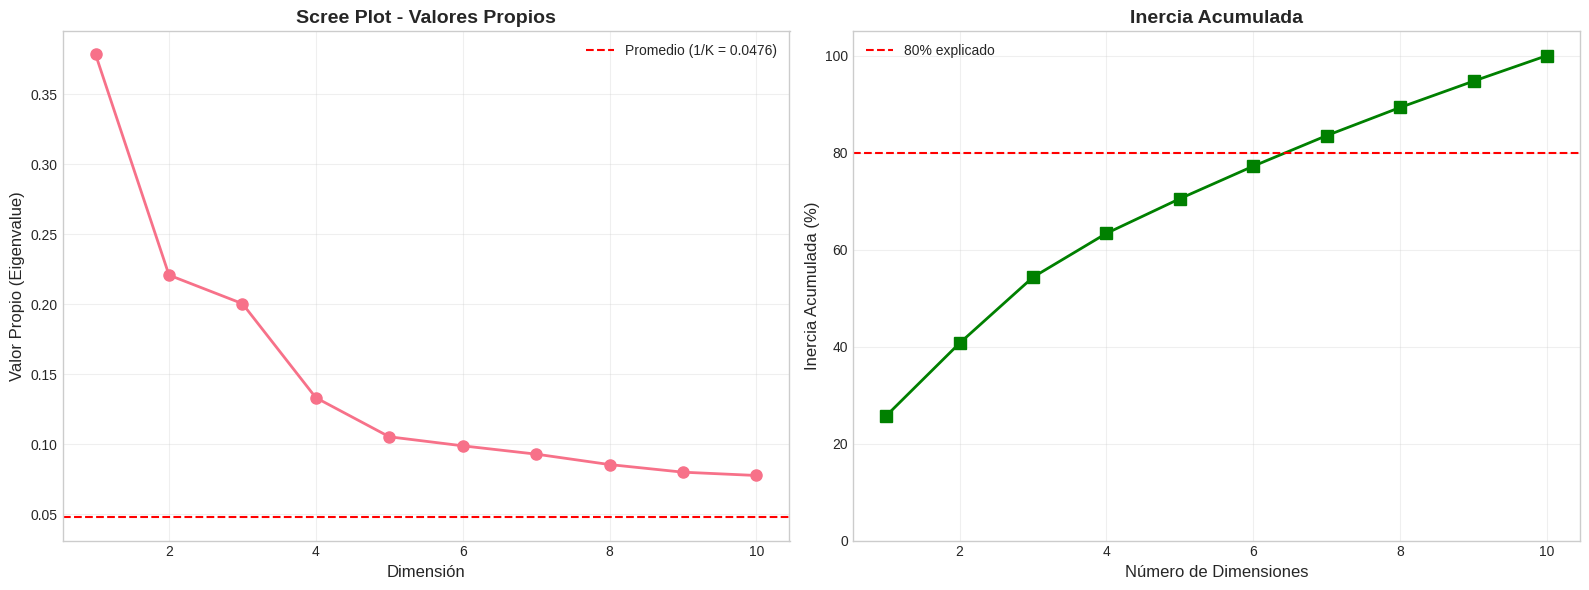


🎯 Criterios para selección de dimensiones:

  • Criterio del codo: Observar gráfico de sedimentación
  • Criterio de Kaiser (eigenvalue > promedio): 10 dimensiones
  • Criterio del 80% de inercia: 7 dimensiones

  ✅ DIMENSIONES RECOMENDADAS: 5


In [ ]:
# ==============================================================================
# 5. ANÁLISIS DE INERCIA Y VARIANZA EXPLICADA
# ==============================================================================

print("\n" + "=" * 80)
print("📊 ANÁLISIS DE INERCIA Y VARIANZA EXPLICADA")
print("=" * 80)

# 5.1 Valores propios (eigenvalues)
eigenvalues = mca_fit.eigenvalues_

# -------------------------------------------------------------
# Cálculo manual de la inercia explicada
# -------------------------------------------------------------
inercia_total = np.sum(eigenvalues)
inercia_explicada_ratio = eigenvalues / inercia_total
inercia_explicada_pct = inercia_explicada_ratio * 100
# -------------------------------------------------------------

inercia_acumulada_pct = np.cumsum(inercia_explicada_pct)

print("\n📈 Valores propios y varianza explicada:")
print(f"\n{'Dim':<6} {'Eigenvalue':<12} {'Inercia %':<12} {'Acumulada %':<12}")
print("-" * 45)
# Usar inercia_explicada_pct e inercia_acumulada_pct para la tabla
for i in range(min(10, len(eigenvalues))):
    print(f"Dim{i+1:<3} {eigenvalues[i]:>10.4f}  {inercia_explicada_pct[i]:>10.2f}  {inercia_acumulada_pct[i]:>10.2f}")

# 5.2 Gráfico de sedimentación (scree plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scree plot
ax1.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', linewidth=2, markersize=8)

num_variables = datos_mca_cat.shape[1]
promedio_eigenvalue = 1 / num_variables
ax1.axhline(y=promedio_eigenvalue, color='r', linestyle='--',
            label=f'Promedio (1/K = {promedio_eigenvalue:.4f})')
ax1.set_xlabel('Dimensión', fontsize=12)
ax1.set_ylabel('Valor Propio (Eigenvalue)', fontsize=12)
ax1.set_title('Scree Plot - Valores Propios', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Inercia acumulada (usamos la versión en porcentaje)
ax2.plot(range(1, len(inercia_acumulada_pct) + 1), inercia_acumulada_pct, 's-',
         linewidth=2, markersize=8, color='green')
ax2.axhline(y=80, color='r', linestyle='--', label='80% explicado')
ax2.set_xlabel('Número de Dimensiones', fontsize=12)
ax2.set_ylabel('Inercia Acumulada (%)', fontsize=12)
ax2.set_title('Inercia Acumulada', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# 5.3 Determinar número óptimo de dimensiones
print("\n🎯 Criterios para selección de dimensiones:")

# Criterio del codo
print(f"\n  • Criterio del codo: Observar gráfico de sedimentación")

# Criterio de Kaiser (eigenvalues > promedio)
promedio = 1 / datos_mca_cat.shape[1]
dims_kaiser = sum(eigenvalues > promedio)
print(f"  • Criterio de Kaiser (eigenvalue > promedio): {dims_kaiser} dimensiones")

# Criterio del 80% de inercia
dims_80 = np.argmax(inercia_acumulada_pct >= 80) + 1
print(f"  • Criterio del 80% de inercia: {dims_80} dimensiones")

# Recomendación
dims_recomendadas = min(dims_kaiser, 5)  # Máximo 5 para interpretabilidad
print(f"\n  ✅ DIMENSIONES RECOMENDADAS: {dims_recomendadas}")


📋 CONTRIBUCIONES DE VARIABLES Y CATEGORÍAS

1️⃣ Contribución de variables a las dimensiones:

📊 DIMENSIÓN 1 (Inercia: 25.70%):
----------------------------------------------------------------------

   Top 15 categorías con mayor peso absoluto:
   Categoría                                     Coordenada  
   ------------------------------------------------------------
   AFILIACIÓN AL SGSSS.1__No_reporta                 1.4913
   SEXO__No_reporta                                  1.4913
   NACIONALIDAD__No_reporta                          1.4913
   TIPO INTERVENCIÓN__Otros_TIPO INTERVENCIÓN        1.2807
   VÍNCULO CON EL JEFE DE HOGAR__No_reporta          1.1733
   OCUPACIÓN__No_reporta                             1.1679
   POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN__13- ...     1.0709
   INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE Q...     1.0456
   ZONA__Otros_ZONA                                  1.0244
   INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE Q...     1.0150
   MANZANA DEL CUIDADO__SI  

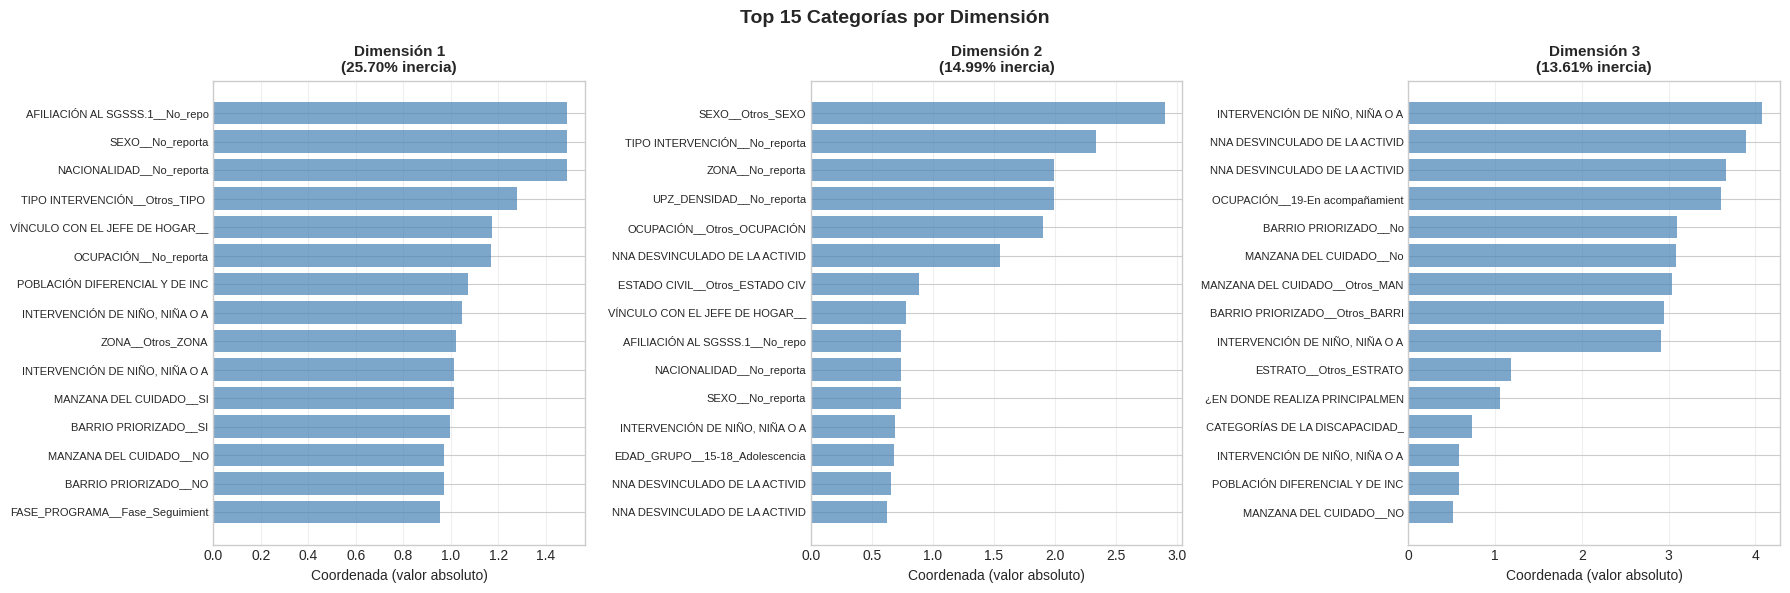

In [ ]:
# ==============================================================================
# 6. CONTRIBUCIONES DE VARIABLES Y CATEGORÍAS
# ==============================================================================
print("\n" + "=" * 80)
print("📋 CONTRIBUCIONES DE VARIABLES Y CATEGORÍAS")
print("=" * 80)

# 6.1 Contribuciones de columnas (variables)
print("\n1️⃣ Contribución de variables a las dimensiones:")
n_dims_analizar = min(dims_recomendadas, 3)

for dim in range(n_dims_analizar):
    # AJUSTE: Usar inercia_explicada_pct
    print(f"\n📊 DIMENSIÓN {dim + 1} (Inercia: {inercia_explicada_pct[dim]:.2f}%):")
    print("-" * 70)

    # Obtener coordenadas para esta dimensión
    coords_dim = coords_categorias.iloc[:, dim].abs().sort_values(ascending=False)

    # Top 15 categorías con mayor contribución
    print(f"\n   Top 15 categorías con mayor peso absoluto:")
    print(f"   {'Categoría':<45} {'Coordenada':<12}")
    print("   " + "-" * 60)

    for cat, coord in coords_dim.head(15).items():
        cat_display = str(cat)[:42] + "..." if len(str(cat)) > 45 else str(cat)
        print(f"   {cat_display:<45} {coord:>10.4f}")

# 6.2 Visualización de contribuciones por variable
print("\n2️⃣ Generando visualización de contribuciones...")
# Crear figura con subplots para primeras 3 dimensiones
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for dim in range(min(3, n_components)):
    coords_dim = coords_categorias.iloc[:, dim].abs().sort_values(ascending=False).head(15)

    axes[dim].barh(range(len(coords_dim)), coords_dim.values, color='steelblue', alpha=0.7)
    axes[dim].set_yticks(range(len(coords_dim)))
    axes[dim].set_yticklabels([str(cat)[:30] for cat in coords_dim.index], fontsize=8)
    axes[dim].set_xlabel('Coordenada (valor absoluto)', fontsize=10)
    # AJUSTE: Usar inercia_explicada_pct
    axes[dim].set_title(f'Dimensión {dim+1}\n({inercia_explicada_pct[dim]:.2f}% inercia)',
                        fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3, axis='x')
    axes[dim].invert_yaxis()

plt.suptitle('Top 15 Categorías por Dimensión', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


🗺️ MAPAS FACTORIALES (BIPLOTS)

1️⃣ Generando mapa factorial de individuos (Dim1 vs Dim2)...


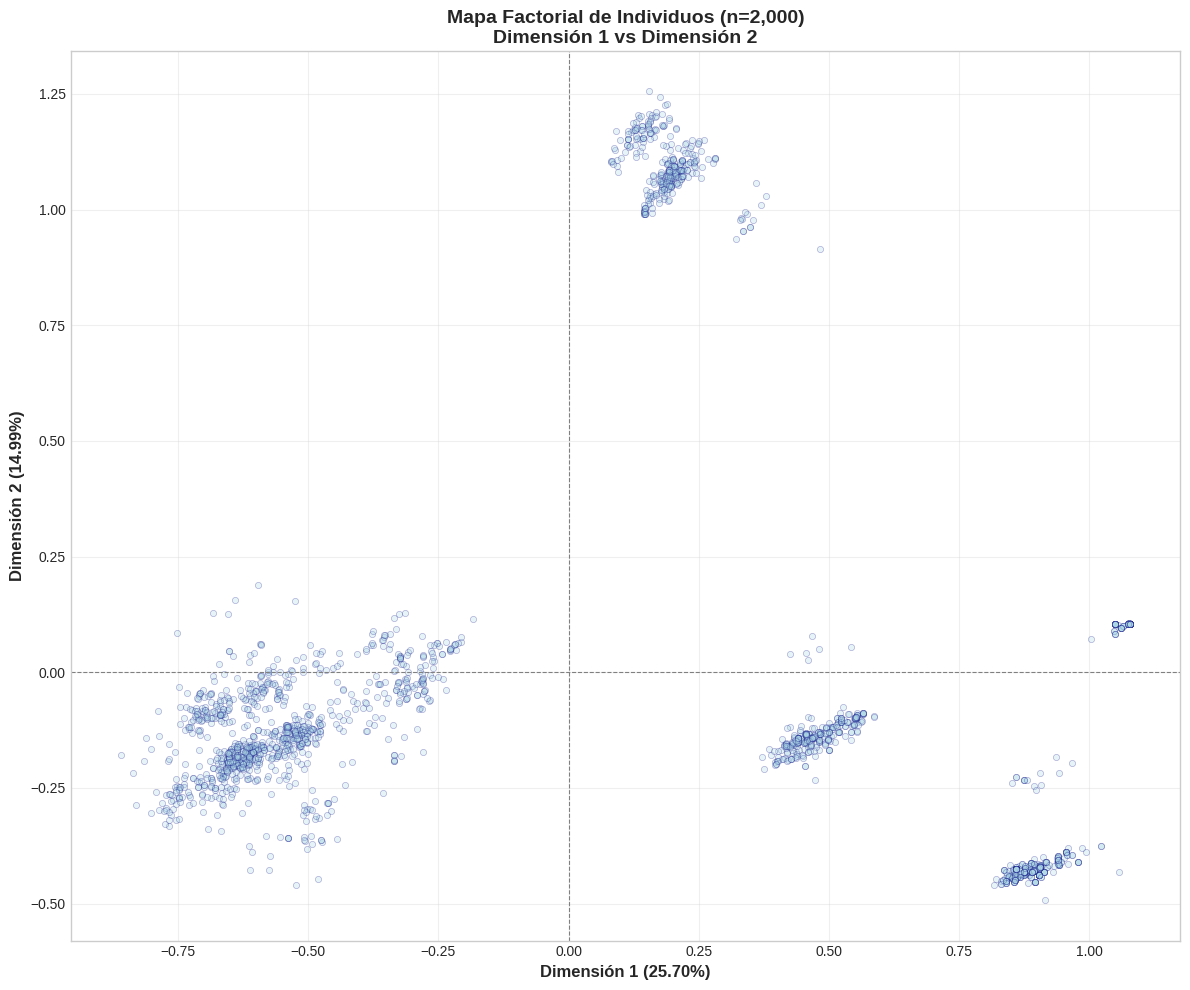


2️⃣ Generando mapa factorial de categorías (Dim1 vs Dim2)...


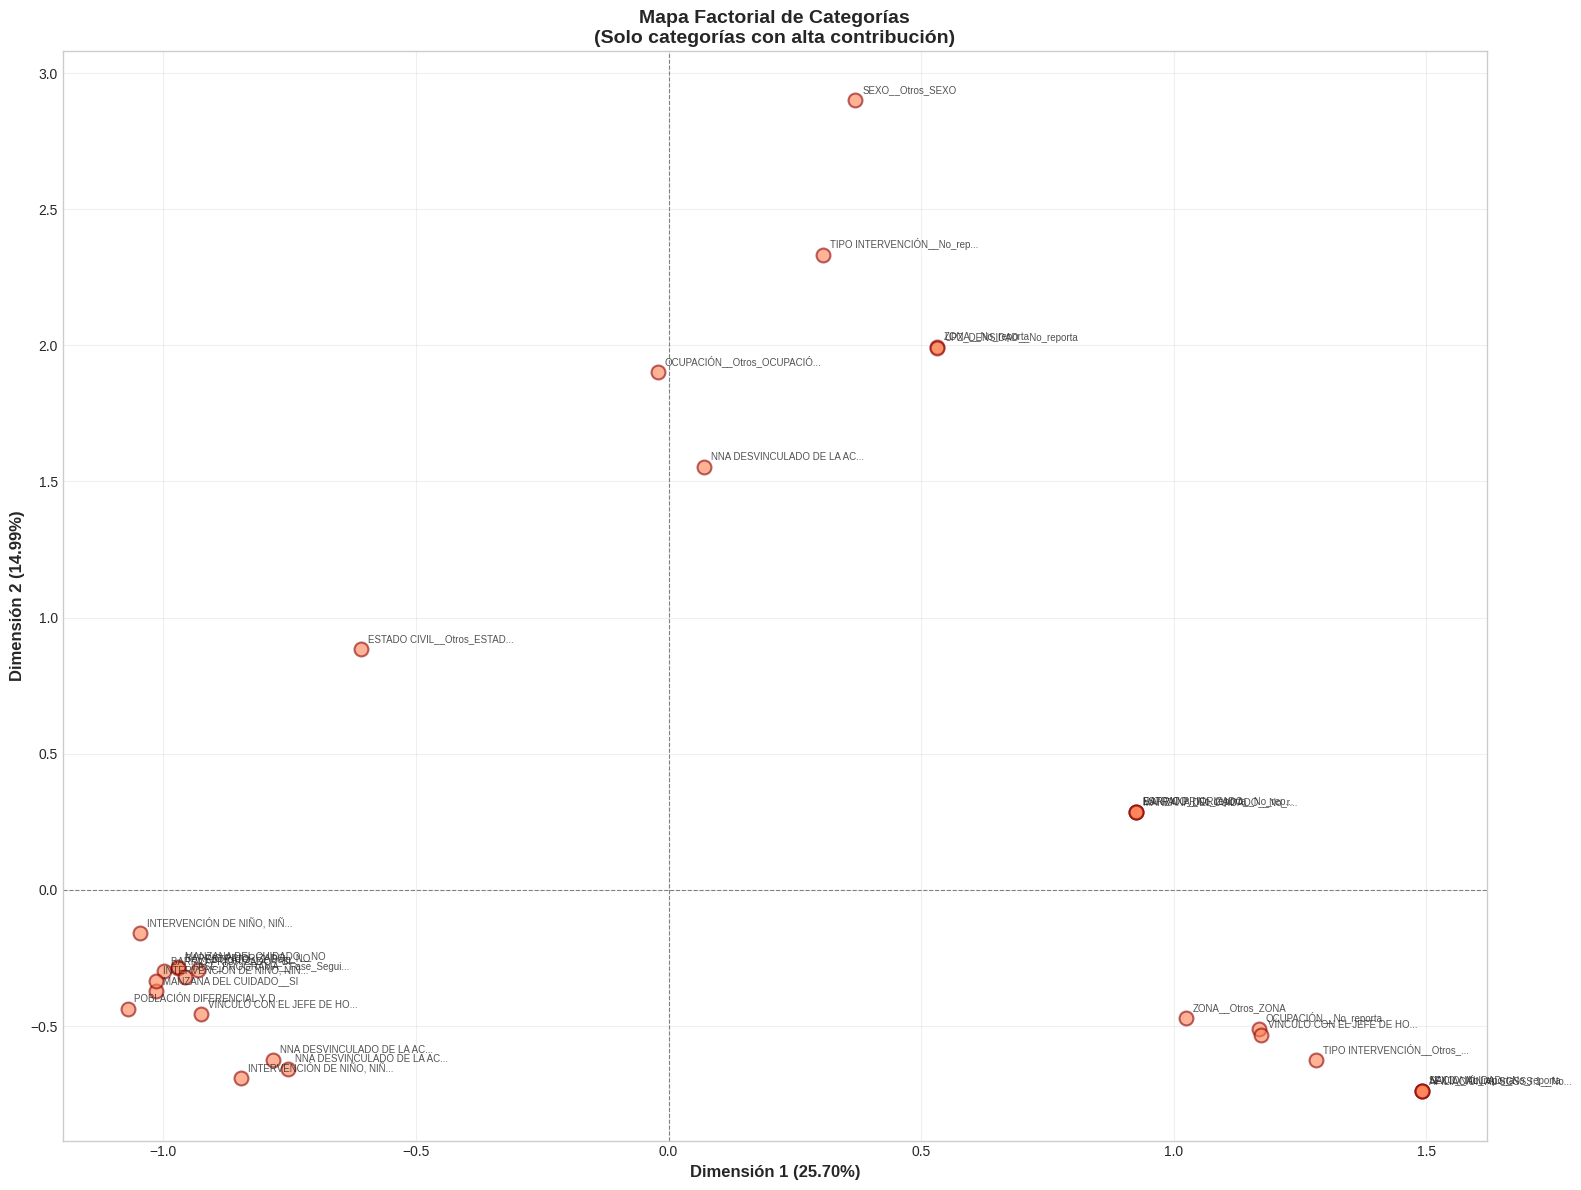


3️⃣ Generando mapas factoriales adicionales...


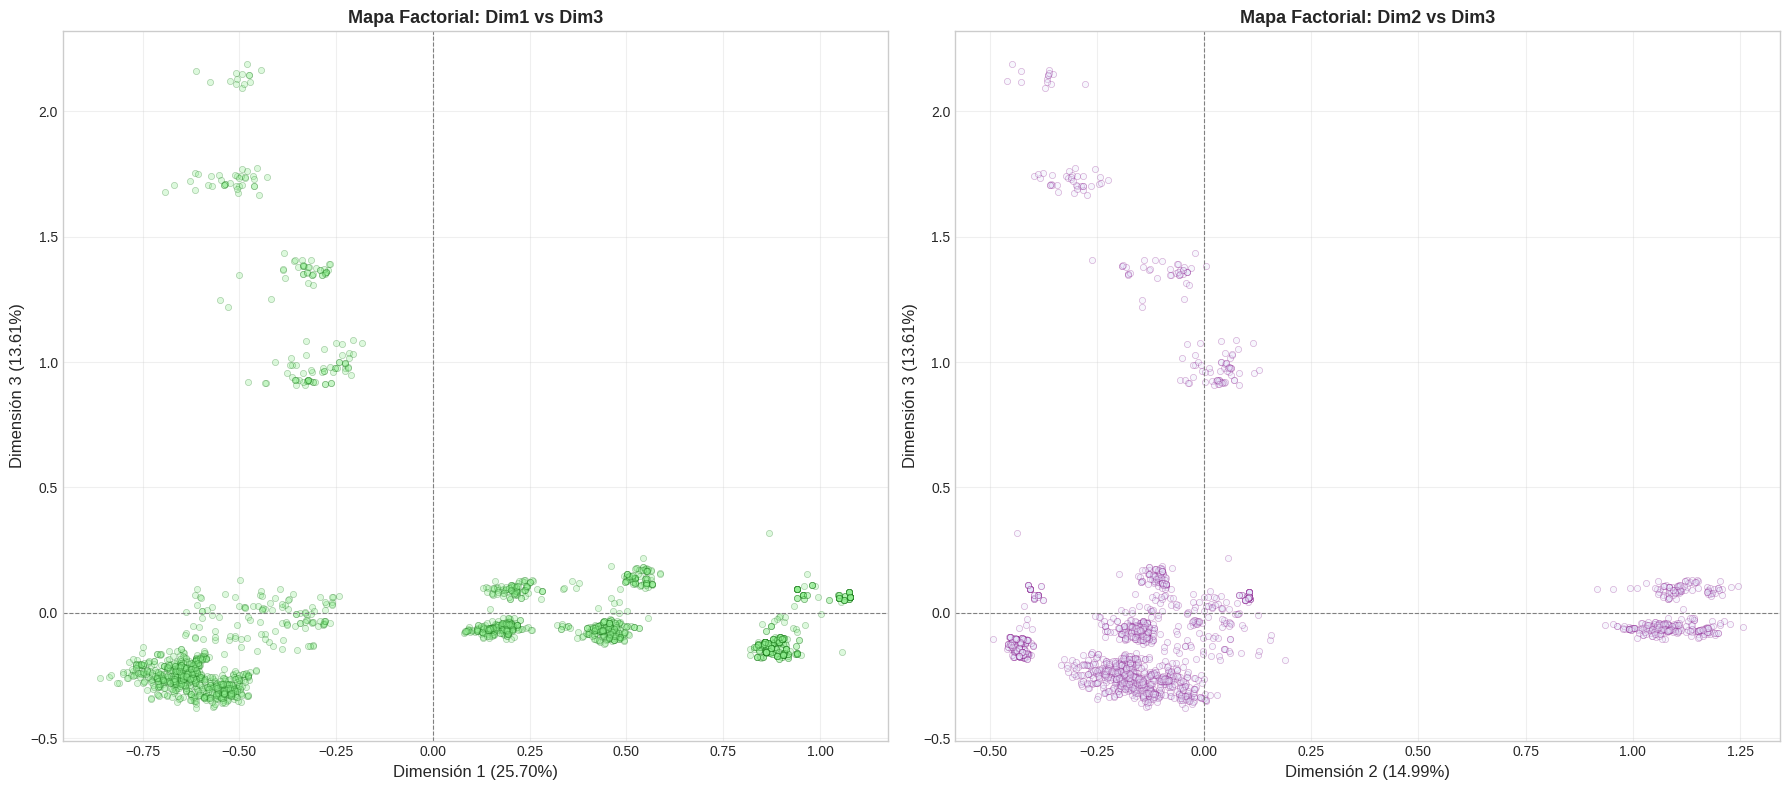

In [ ]:
# ==============================================================================
# 7. MAPAS FACTORIALES (BIPLOTS)
# ==============================================================================
print("\n" + "=" * 80)
print("🗺️ MAPAS FACTORIALES (BIPLOTS)")
print("=" * 80)

# 7.1 Mapa factorial Dim1 vs Dim2 (Individuos)
print("\n1️⃣ Generando mapa factorial de individuos (Dim1 vs Dim2)...")
fig, ax = plt.subplots(figsize=(12, 10))

# Plot individuos (muestra aleatoria para claridad)
muestra_size = min(2000, len(coords_individuos))
indices_muestra = np.random.choice(len(coords_individuos), muestra_size, replace=False)

ax.scatter(coords_individuos.iloc[indices_muestra, 0],
           coords_individuos.iloc[indices_muestra, 1],
           alpha=0.3, s=20, c='lightblue', edgecolors='navy', linewidths=0.5)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel(f'Dimensión 1 ({inercia_explicada_pct[0]:.2f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Dimensión 2 ({inercia_explicada_pct[1]:.2f}%)', fontsize=12, fontweight='bold')
ax.set_title(f'Mapa Factorial de Individuos (n={muestra_size:,})\nDimensión 1 vs Dimensión 2',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7.2 Mapa factorial con categorías
print("\n2️⃣ Generando mapa factorial de categorías (Dim1 vs Dim2)...")
fig, ax = plt.subplots(figsize=(16, 12))

# Plot categorías (solo las más importantes)
coords_dim1 = coords_categorias.iloc[:, 0]
coords_dim2 = coords_categorias.iloc[:, 1]

# Filtrar categorías con alta contribución
umbral_contrib = np.percentile(np.sqrt(coords_dim1**2 + coords_dim2**2), 70)
mask_importantes = np.sqrt(coords_dim1**2 + coords_dim2**2) > umbral_contrib

ax.scatter(coords_dim1[mask_importantes],
           coords_dim2[mask_importantes],
           s=100, c='coral', alpha=0.6, edgecolors='darkred', linewidths=1.5)

# Etiquetar categorías importantes
for idx, (cat, x, y) in enumerate(zip(coords_categorias.index[mask_importantes],
                                       coords_dim1[mask_importantes],
                                       coords_dim2[mask_importantes])):
    label = str(cat)[:25] + "..." if len(str(cat)) > 25 else str(cat)
    ax.annotate(label, (x, y), fontsize=7, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

ax.set_xlabel(f'Dimensión 1 ({inercia_explicada_pct[0]:.2f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Dimensión 2 ({inercia_explicada_pct[1]:.2f}%)', fontsize=12, fontweight='bold')
ax.set_title('Mapa Factorial de Categorías\n(Solo categorías con alta contribución)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7.3 Mapas adicionales (Dim1 vs Dim3, Dim2 vs Dim3)
if n_components >= 3:
    print("\n3️⃣ Generando mapas factoriales adicionales...")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

    # Dim1 vs Dim3
    ax1.scatter(coords_individuos.iloc[indices_muestra, 0],
                coords_individuos.iloc[indices_muestra, 2],
                alpha=0.3, s=20, c='lightgreen', edgecolors='darkgreen', linewidths=0.5)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax1.set_xlabel(f'Dimensión 1 ({inercia_explicada_pct[0]:.2f}%)', fontsize=12)
    ax1.set_ylabel(f'Dimensión 3 ({inercia_explicada_pct[2]:.2f}%)', fontsize=12)
    ax1.set_title('Mapa Factorial: Dim1 vs Dim3', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Dim2 vs Dim3
    ax2.scatter(coords_individuos.iloc[indices_muestra, 1],
                coords_individuos.iloc[indices_muestra, 2],
                alpha=0.3, s=20, c='lavender', edgecolors='purple', linewidths=0.5)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax2.set_xlabel(f'Dimensión 2 ({inercia_explicada_pct[1]:.2f}%)', fontsize=12)
    ax2.set_ylabel(f'Dimensión 3 ({inercia_explicada_pct[2]:.2f}%)', fontsize=12)
    ax2.set_title('Mapa Factorial: Dim2 vs Dim3', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


👥 ANÁLISIS DE PERFILES (CLUSTERING)

1️⃣ Determinando número óptimo de clusters...
   Probando de 2 a 10 clusters...
      k=2: Silhouette=0.377, Davies-Bouldin=1.288
      k=4: Silhouette=0.559, Davies-Bouldin=0.711
      k=6: Silhouette=0.503, Davies-Bouldin=0.732
      k=8: Silhouette=0.416, Davies-Bouldin=0.923
      k=10: Silhouette=0.413, Davies-Bouldin=0.975


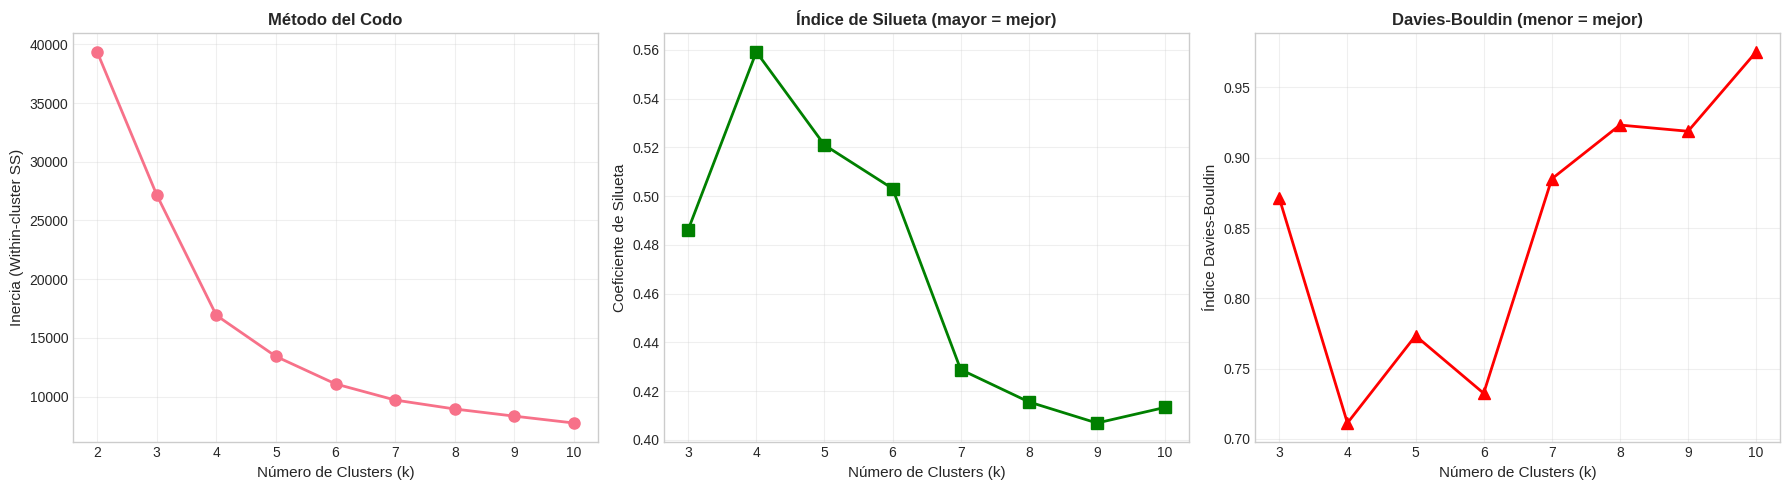


   ✅ Número óptimo de clusters (Silhouette): k = 4

2️⃣ Ejecutando clustering con k=4...
   ✅ Clustering completado

   Distribución de clusters:
CLUSTER
0    23672
1    20065
2     4661
3     8075
Name: count, dtype: int64

3️⃣ Visualizando clusters en mapa factorial...


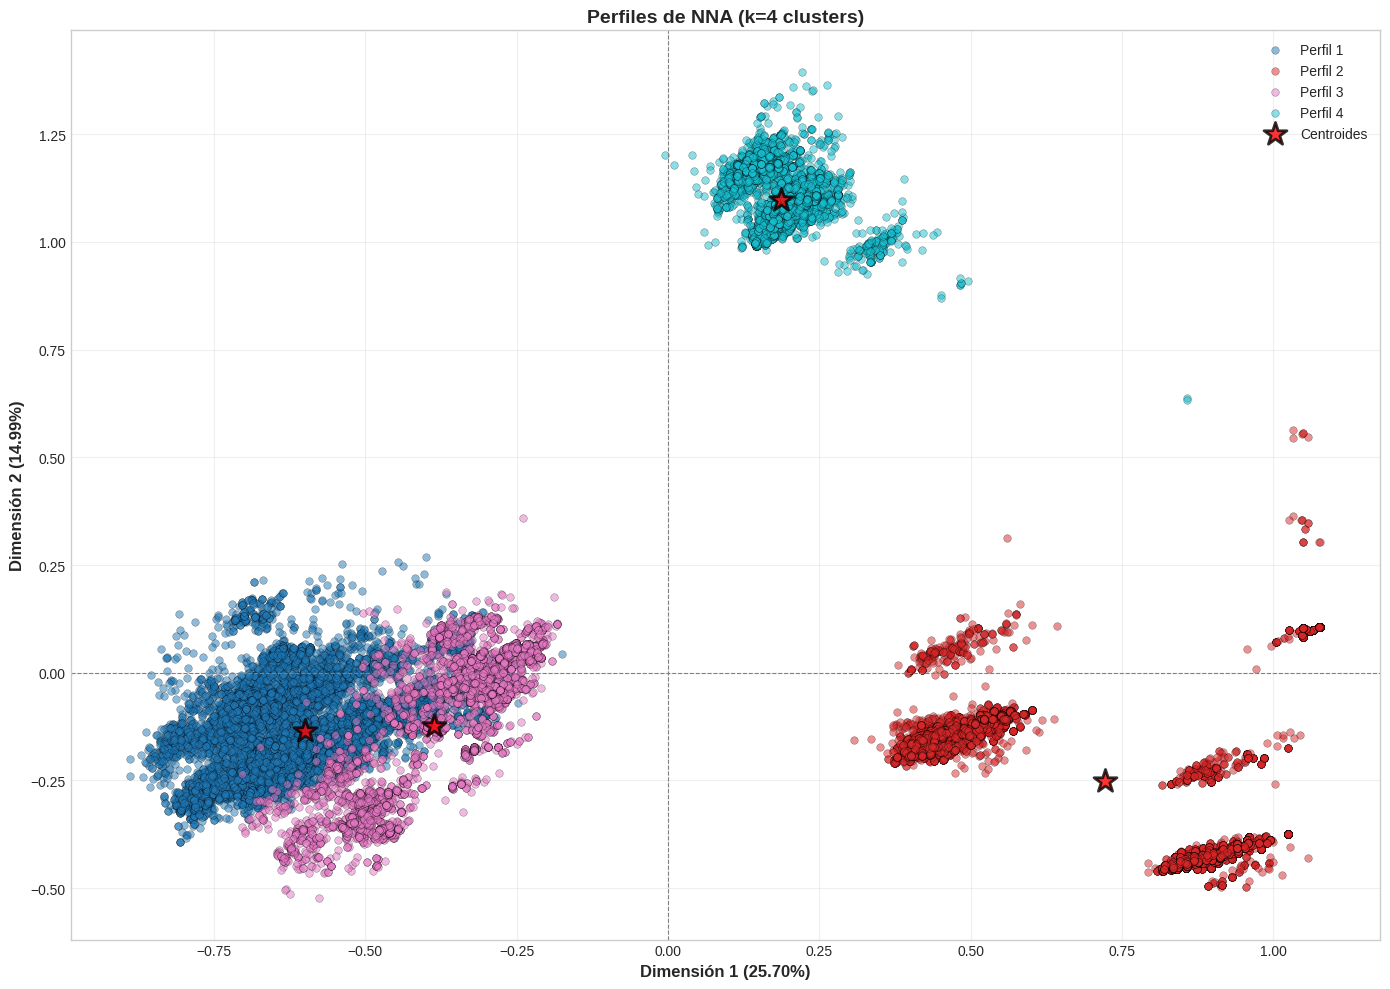

In [ ]:
# ==============================================================================
# 8. ANÁLISIS DE PERFILES (CLUSTERING)
# ==============================================================================
print("\n" + "=" * 80)
print("👥 ANÁLISIS DE PERFILES (CLUSTERING)")
print("=" * 80)

# 8.1 Determinar número óptimo de clusters
print("\n1️⃣ Determinando número óptimo de clusters...")
# Usar primeras dimensiones recomendadas
X_clustering = coords_individuos.iloc[:, :dims_recomendadas]

# Método del codo e índices de validación
k_range = range(2, 11)
inertias = []
silhouettes = []
davies_bouldins = []
print(f"   Probando de 2 a 10 clusters...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clustering)

    inertias.append(kmeans.inertia_)
    if len(np.unique(labels)) > 1:
        silhouettes.append(silhouette_score(X_clustering, labels))
        davies_bouldins.append(davies_bouldin_score(X_clustering, labels))
    else: # Manejar el caso de un solo cluster si el random_state produce eso
        silhouettes.append(-1)
        davies_bouldins.append(np.inf)

    if k % 2 == 0:
        print(f"      k={k}: Silhouette={silhouettes[-1]:.3f}, Davies-Bouldin={davies_bouldins[-1]:.3f}")

# Visualizar métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(k_range, inertias, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inercia (Within-cluster SS)', fontsize=11)
axes[0].set_title('Método del Codo', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Ajustar rangos para los gráficos de índices
k_range_indices = k_range[1:] # Si k=2 es el primer valor válido
silhouettes_valid = silhouettes[1:]
davies_bouldins_valid = davies_bouldins[1:]

axes[1].plot(k_range_indices, silhouettes_valid, 's-', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[1].set_ylabel('Coeficiente de Silueta', fontsize=11)
axes[1].set_title('Índice de Silueta (mayor = mejor)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range_indices, davies_bouldins_valid, '^-', linewidth=2, markersize=8, color='red')
axes[2].set_xlabel('Número de Clusters (k)', fontsize=11)
axes[2].set_ylabel('Índice Davies-Bouldin', fontsize=11)
axes[2].set_title('Davies-Bouldin (menor = mejor)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Seleccionar k óptimo
if silhouettes_valid:
    k_optimo = k_range_indices[np.argmax(silhouettes_valid)]
else:
    k_optimo = 3 # Valor por defecto si no se puede calcular Silueta
print(f"\n   ✅ Número óptimo de clusters (Silhouette): k = {k_optimo}")

# 8.2 Clustering final
print(f"\n2️⃣ Ejecutando clustering con k={k_optimo}...")
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(X_clustering)

# Agregar clusters al dataset
datos_mca_clustered = datos_mca.copy()
datos_mca_clustered['CLUSTER'] = clusters
datos_mca_clustered['CLUSTER'] = datos_mca_clustered['CLUSTER'].astype(str)
print(f"   ✅ Clustering completado")
print(f"\n   Distribución de clusters:")
print(datos_mca_clustered['CLUSTER'].value_counts().sort_index())

# 8.3 Visualizar clusters en espacio factorial
print("\n3️⃣ Visualizando clusters en mapa factorial...")
fig, ax = plt.subplots(figsize=(14, 10))

# Plot por cluster
colors = plt.cm.tab10(np.linspace(0, 1, k_optimo))
for i in range(k_optimo):
    mask_cluster = clusters == i
    ax.scatter(coords_individuos.iloc[mask_cluster, 0],
               coords_individuos.iloc[mask_cluster, 1],
               c=[colors[i]], label=f'Perfil {i+1}',
               alpha=0.5, s=30, edgecolors='black', linewidths=0.3)

# Centroides
centroides_2d = kmeans_final.cluster_centers_[:, :2]
ax.scatter(centroides_2d[:, 0], centroides_2d[:, 1],
           c='red', s=300, alpha=0.8, edgecolors='black', linewidths=2,
           marker='*', label='Centroides')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
# AJUSTE: Usar inercia_explicada_pct
ax.set_xlabel(f'Dimensión 1 ({inercia_explicada_pct[0]:.2f}%)', fontsize=12, fontweight='bold')
# AJUSTE: Usar inercia_explicada_pct
ax.set_ylabel(f'Dimensión 2 ({inercia_explicada_pct[1]:.2f}%)', fontsize=12, fontweight='bold')
ax.set_title(f'Perfiles de NNA (k={k_optimo} clusters)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 9. CARACTERIZACIÓN DE PERFILES
# ==============================================================================
print("\n" + "=" * 80)
print("🔍 CARACTERIZACIÓN DE PERFILES")
print("=" * 80)

# 9.1 Análisis descriptivo por cluster
print("\n📊 Perfil de cada cluster:\n")
for cluster_id in range(k_optimo):
    print("=" * 80)
    porcentaje_cluster = sum(clusters == cluster_id)/len(clusters)*100
    print(f"PERFIL {cluster_id + 1} (n={sum(clusters == cluster_id):,} NNA, {porcentaje_cluster:.1f}%)")
    print("=" * 80)

    # Filtrar datos del cluster
    datos_cluster = datos_mca_clustered[datos_mca_clustered['CLUSTER'] == str(cluster_id)]

    # Variables clave para caracterizar
    vars_caracterizacion = ['SEXO', 'EDAD_GRUPO', 'ESTRATO', 'NACIONALIDAD',
                            'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL']

    vars_disponibles = [v for v in vars_caracterizacion if v in datos_cluster.columns]

    for var in vars_disponibles[:5]:  # Top 5 variables
        print(f"\n📌 {var}:")
        freq = datos_cluster[var].value_counts(normalize=True).head(3)
        for cat, pct in freq.items():
            print(f"   • {cat}: {pct*100:.1f}%")
print("\n" + "=" * 80)


🔍 CARACTERIZACIÓN DE PERFILES

📊 Perfil de cada cluster:

PERFIL 1 (n=23,672 NNA, 41.9%)

📌 SEXO:
   • 1- Hombre: 51.1%
   • 2- Mujer: 48.9%

📌 EDAD_GRUPO:
   • 6-10_Infancia: 34.1%
   • 0-5_Primera_Infancia: 27.1%
   • 11-14_Preadolescencia: 25.5%

📌 ESTRATO:
   • 2. Bajo: 65.0%
   • 3. Medio-bajo: 18.7%
   • 1. Bajo-bajo: 16.2%

📌 NACIONALIDAD:
   • Colombia: 82.3%
   • Venezuela (Bolivarian Republic of): 17.6%
   • Otros_NACIONALIDAD: 0.1%

📌 NNA DESVINCULADO DE LA ACTIVIDAD LABORAL:
   • SI: 77.3%
   • NO: 19.1%
   • No_reporta: 3.6%
PERFIL 2 (n=20,065 NNA, 35.5%)

📌 SEXO:
   • No_reporta: 55.7%
   • 1- Hombre: 22.3%
   • 2- Mujer: 22.1%

📌 EDAD_GRUPO:
   • No_reporta: 100.0%

📌 ESTRATO:
   • No_reporta: 100.0%

📌 NACIONALIDAD:
   • No_reporta: 55.7%
   • Colombia: 36.9%
   • Venezuela (Bolivarian Republic of): 7.3%

📌 NNA DESVINCULADO DE LA ACTIVIDAD LABORAL:
   • SI: 83.6%
   • NO: 13.6%
   • No_reporta: 2.7%
PERFIL 3 (n=4,661 NNA, 8.3%)

📌 SEXO:
   • 1- Hombre: 50.1%
   • 2- Mu

In [ ]:
# ==============================================================================
# 10. EXPORTACIÓN DE RESULTADOS
# ==============================================================================
print("\n" + "=" * 80)
print("💾 EXPORTACIÓN DE RESULTADOS")
print("=" * 80)

ruta_salida = "/content/drive/MyDrive/Python/Proyecto NNA/"

# 10.1 Dataset con clusters
datos_mca_clustered.to_csv(ruta_salida + "datos_con_clusters.csv", index=False)
print(f"\n✅ Dataset con clusters guardado")

# 10.2 Coordenadas factoriales
coords_individuos_export = coords_individuos.copy()
coords_individuos_export['CLUSTER'] = clusters
coords_individuos_export.to_csv(ruta_salida + "coordenadas_factoriales.csv", index=False)
print(f"✅ Coordenadas factoriales guardadas")

# 10.3 Resultados MCA
resultados_mca = pd.DataFrame({
    'Dimension': range(1, len(eigenvalues) + 1),
    'Eigenvalue': eigenvalues,
    'Inercia_%': inercia_explicada_pct,
    'Inercia_Acumulada_%': inercia_acumulada_pct
})
resultados_mca.to_excel(ruta_salida + "resultados_mca.xlsx", index=False)
print(f"✅ Resultados MCA guardados")

# 10.4 Coordenadas de categorías
coords_categorias.to_csv(ruta_salida + "coordenadas_categorias.csv")
print(f"✅ Coordenadas de categorías guardadas")

# 10.5 Caracterización de clusters
caracterizacion_clusters = []
for cluster_id in range(k_optimo):
    datos_cluster = datos_mca_clustered[datos_mca_clustered['CLUSTER'] == str(cluster_id)]

    perfil = {
        'Cluster': f'Perfil_{cluster_id + 1}',
        'N_NNA': len(datos_cluster),
        'Porcentaje': len(datos_cluster) / len(datos_mca_clustered) * 100
    }

    # Agregar características principales
    for var in datos_cluster.columns[:10]:  # Primeras 10 variables
        if var != 'CLUSTER':
            moda = datos_cluster[var].mode()[0] if len(datos_cluster[var].mode()) > 0 else 'N/A'
            freq = datos_cluster[var].value_counts(normalize=True).iloc[0] * 100 if len(datos_cluster[var]) > 0 else 0
            perfil[f'{var}_principal'] = f"{moda} ({freq:.1f}%)"
    caracterizacion_clusters.append(perfil)
df_caracterizacion = pd.DataFrame(caracterizacion_clusters)
df_caracterizacion.to_excel(ruta_salida + "caracterizacion_perfiles.xlsx", index=False)
print(f"✅ Caracterización de perfiles guardada")


💾 EXPORTACIÓN DE RESULTADOS

✅ Dataset con clusters guardado
✅ Coordenadas factoriales guardadas
✅ Resultados MCA guardados
✅ Coordenadas de categorías guardadas
✅ Caracterización de perfiles guardada


In [ ]:
# ==============================================================================
# 11. INTERPRETACIÓN Y VALIDACIÓN - ✅ AJUSTADO
# ==============================================================================
print("\n" + "=" * 80)
print("🎓 INTERPRETACIÓN Y VALIDACIÓN DEL MODELO")
print("=" * 80)

# 11.1 Calidad del modelo MCA
print("\n1️⃣ CALIDAD DEL MODELO MCA:")
# AJUSTE: Usar inercia_acumulada_pct
inercia_rec = inercia_acumulada_pct[dims_recomendadas-1]
print(f"\n   • Inercia total explicada ({dims_recomendadas} dims): {inercia_rec:.2f}%")
print(f"   • Dimensiones significativas (Kaiser): {dims_kaiser}")
print(f"   • Número de categorías analizadas: {len(coords_categorias)}")

# Interpretación básica
if inercia_rec > 50:
    print(f"   ✅ Modelo con buena capacidad explicativa (>{50}%)")
elif inercia_rec > 30:
    print(f"   ⚠️ Modelo con capacidad explicativa moderada (30-50%)")
else:
    print(f"   ⚠️ Modelo con baja capacidad explicativa (<30%)")

# 11.2 Calidad del clustering
print("\n2️⃣ CALIDAD DEL CLUSTERING:")
max_silueta = max(silhouettes_valid) if silhouettes_valid else 0
db_index = davies_bouldins_valid[k_optimo-2] if k_optimo-2 < len(davies_bouldins_valid) else np.inf

print(f"\n   • Número de clusters: {k_optimo}")
print(f"   • Coeficiente de Silueta: {max_silueta:.3f}")
print(f"   • Índice Davies-Bouldin: {db_index:.3f}")

if max_silueta > 0.5:
    print(f"   ✅ Clustering con buena separación entre perfiles")
elif max_silueta > 0.3:
    print(f"   ⚠️ Clustering con separación moderada entre perfiles")
else:
    print(f"   ⚠️ Clustering con baja separación entre perfiles")


🎓 INTERPRETACIÓN Y VALIDACIÓN DEL MODELO

1️⃣ CALIDAD DEL MODELO MCA:

   • Inercia total explicada (5 dims): 70.49%
   • Dimensiones significativas (Kaiser): 10
   • Número de categorías analizadas: 100
   ✅ Modelo con buena capacidad explicativa (>50%)

2️⃣ CALIDAD DEL CLUSTERING:

   • Número de clusters: 4
   • Coeficiente de Silueta: 0.559
   • Índice Davies-Bouldin: 0.773
   ✅ Clustering con buena separación entre perfiles


In [ ]:

# ==============================================================================
# 12. ANÁLISIS COMPLEMENTARIO: TEST CHI-CUADRADO
# ==============================================================================

print("\n" + "=" * 80)
print("📊 ANÁLISIS COMPLEMENTARIO: ASOCIACIONES SIGNIFICATIVAS")
print("=" * 80)

# Variables clave para analizar asociación con clusters
vars_test = ['SEXO', 'EDAD_GRUPO', 'ESTRATO', 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL']
vars_test = [v for v in vars_test if v in datos_mca_clustered.columns]

print(f"\nRealizando test Chi-cuadrado entre CLUSTER y variables clave:\n")
print(f"{'Variable':<50} {'Chi2':<15} {'p-valor':<15} {'Asociación':<15}")
print("-" * 95)

resultados_chi2 = []

for var in vars_test:
    try:
        tabla_contingencia = pd.crosstab(datos_mca_clustered['CLUSTER'],
                                          datos_mca_clustered[var])
        chi2, p_valor, dof, expected = stats.chi2_contingency(tabla_contingencia)

        # Determinar significancia
        if p_valor < 0.001:
            sig = "***"
        elif p_valor < 0.01:
            sig = "**"
        elif p_valor < 0.05:
            sig = "*"
        else:
            sig = "ns"

        print(f"{var:<50} {chi2:>12.2f}   {p_valor:>12.4f}   {sig:>12}")

        resultados_chi2.append({
            'Variable': var,
            'Chi2': chi2,
            'p_valor': p_valor,
            'Significancia': sig
        })
    except Exception as e:
        print(f"{var:<50} {'Error':<15} {'N/A':<15} {'N/A':<15}")

print("\n   Leyenda: *** p<0.001, ** p<0.01, * p<0.05, ns no significativo")

# Guardar resultados chi2
if resultados_chi2:
    df_chi2 = pd.DataFrame(resultados_chi2)
    df_chi2.to_excel(ruta_salida + "test_asociaciones_clusters.xlsx", index=False)
    print(f"\n   ✅ Resultados de test Chi-cuadrado guardados")


📊 ANÁLISIS COMPLEMENTARIO: ASOCIACIONES SIGNIFICATIVAS

Realizando test Chi-cuadrado entre CLUSTER y variables clave:

Variable                                           Chi2            p-valor         Asociación     
-----------------------------------------------------------------------------------------------
SEXO                                                   25269.50         0.0000            ***
EDAD_GRUPO                                             56571.79         0.0000            ***
ESTRATO                                                56533.32         0.0000            ***
NNA DESVINCULADO DE LA ACTIVIDAD LABORAL               67035.56         0.0000            ***

   Leyenda: *** p<0.001, ** p<0.01, * p<0.05, ns no significativo

   ✅ Resultados de test Chi-cuadrado guardados



📊 DASHBOARD RESUMEN DEL ANÁLISIS


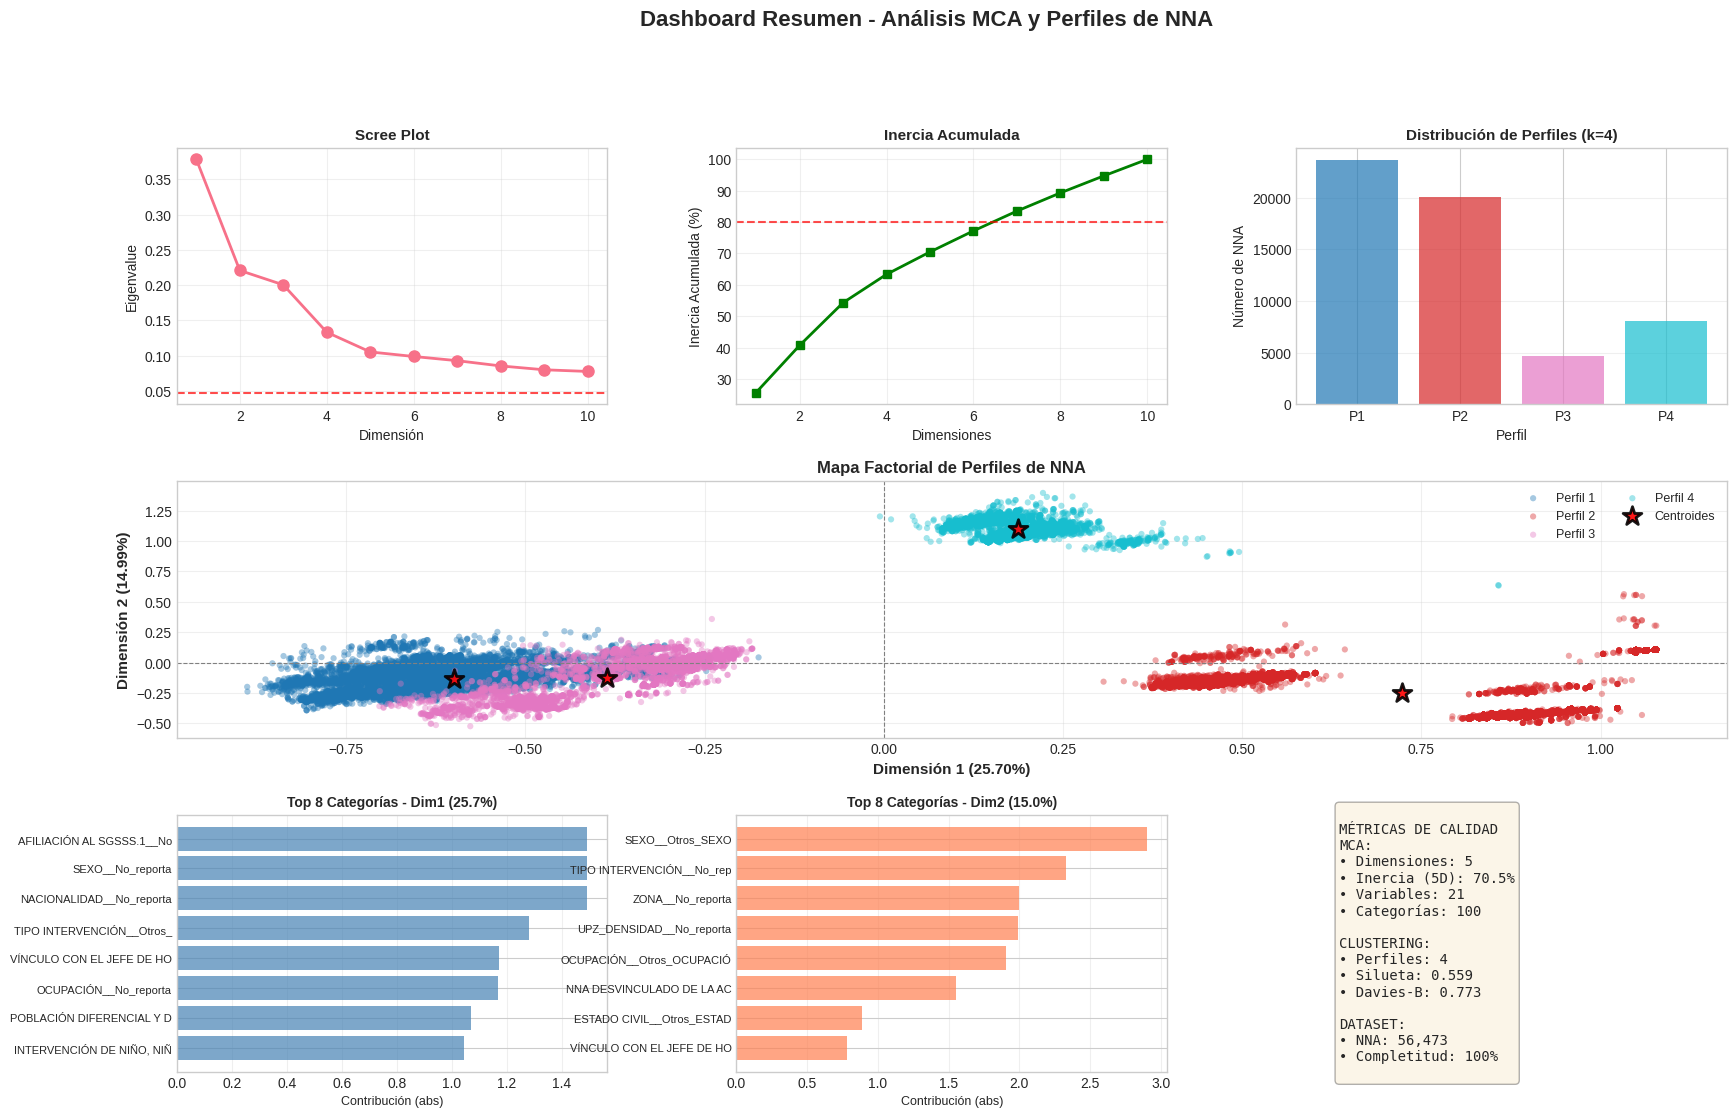


✅ Dashboard guardado como imagen


In [ ]:
# ==============================================================================
# 13. VISUALIZACIÓN FINAL: DASHBOARD RESUMEN - ✅ AJUSTADO
# ==============================================================================
print("\n" + "=" * 80)
print("📊 DASHBOARD RESUMEN DEL ANÁLISIS")
print("=" * 80)
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Scree plot
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, min(10, len(eigenvalues)) + 1),
         eigenvalues[:min(10, len(eigenvalues))], 'o-', linewidth=2, markersize=8)
ax1.axhline(y=1/datos_mca_cat.shape[1], color='r', linestyle='--', alpha=0.7)
ax1.set_xlabel('Dimensión', fontsize=10)
ax1.set_ylabel('Eigenvalue', fontsize=10)
ax1.set_title('Scree Plot', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Inercia acumulada
ax2 = fig.add_subplot(gs[0, 1])
# AJUSTE: Usar inercia_acumulada_pct
ax2.plot(range(1, len(inercia_acumulada_pct) + 1), inercia_acumulada_pct, 's-',
         linewidth=2, markersize=6, color='green')
ax2.axhline(y=80, color='r', linestyle='--', alpha=0.7)
ax2.set_xlabel('Dimensiones', fontsize=10)
ax2.set_ylabel('Inercia Acumulada (%)', fontsize=10)
ax2.set_title('Inercia Acumulada', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Distribución de clusters
ax3 = fig.add_subplot(gs[0, 2])
cluster_counts = datos_mca_clustered['CLUSTER'].value_counts().sort_index()
colors_bar = plt.cm.tab10(np.linspace(0, 1, k_optimo))
ax3.bar(range(len(cluster_counts)), cluster_counts.values, color=colors_bar, alpha=0.7)
ax3.set_xlabel('Perfil', fontsize=10)
ax3.set_ylabel('Número de NNA', fontsize=10)
ax3.set_title(f'Distribución de Perfiles (k={k_optimo})', fontsize=11, fontweight='bold')
ax3.set_xticks(range(len(cluster_counts)))
ax3.set_xticklabels([f'P{i+1}' for i in range(len(cluster_counts))])
ax3.grid(True, alpha=0.3, axis='y')

# 4. Mapa factorial principal (individuos coloreados por cluster)
ax4 = fig.add_subplot(gs[1, :])
for i in range(k_optimo):
    mask_cluster = clusters == i
    ax4.scatter(coords_individuos.iloc[mask_cluster, 0],
                coords_individuos.iloc[mask_cluster, 1],
                c=[colors[i]], label=f'Perfil {i+1}',
                alpha=0.4, s=20, edgecolors='none')

ax4.scatter(centroides_2d[:, 0], centroides_2d[:, 1],
            c='red', s=200, alpha=0.9, edgecolors='black', linewidths=2,
            marker='*', label='Centroides', zorder=5)
ax4.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax4.axvline(0, color='gray', linestyle='--', linewidth=0.8)
# AJUSTE: Usar inercia_explicada_pct
ax4.set_xlabel(f'Dimensión 1 ({inercia_explicada_pct[0]:.2f}%)', fontsize=11, fontweight='bold')
# AJUSTE: Usar inercia_explicada_pct
ax4.set_ylabel(f'Dimensión 2 ({inercia_explicada_pct[1]:.2f}%)', fontsize=11, fontweight='bold')
ax4.set_title('Mapa Factorial de Perfiles de NNA', fontsize=12, fontweight='bold')
ax4.legend(loc='upper right', fontsize=9, ncol=2)
ax4.grid(True, alpha=0.3)

# 5. Top variables por dimensión 1
ax5 = fig.add_subplot(gs[2, 0])
coords_dim1_top = coords_categorias.iloc[:, 0].abs().sort_values(ascending=False).head(8)
ax5.barh(range(len(coords_dim1_top)), coords_dim1_top.values, color='steelblue', alpha=0.7)
ax5.set_yticks(range(len(coords_dim1_top)))
ax5.set_yticklabels([str(cat)[:25] for cat in coords_dim1_top.index], fontsize=8)
ax5.set_xlabel('Contribución (abs)', fontsize=9)
ax5.set_title(f'Top 8 Categorías - Dim1 ({inercia_explicada_pct[0]:.1f}%)', fontsize=10, fontweight='bold')
ax5.invert_yaxis()
ax5.grid(True, alpha=0.3, axis='x')

# 6. Top variables por dimensión 2
ax6 = fig.add_subplot(gs[2, 1])
coords_dim2_top = coords_categorias.iloc[:, 1].abs().sort_values(ascending=False).head(8)
ax6.barh(range(len(coords_dim2_top)), coords_dim2_top.values, color='coral', alpha=0.7)
ax6.set_yticks(range(len(coords_dim2_top)))
ax6.set_yticklabels([str(cat)[:25] for cat in coords_dim2_top.index], fontsize=8)
ax6.set_xlabel('Contribución (abs)', fontsize=9)
ax6.set_title(f'Top 8 Categorías - Dim2 ({inercia_explicada_pct[1]:.1f}%)', fontsize=10, fontweight='bold')
ax6.invert_yaxis()
ax6.grid(True, alpha=0.3, axis='x')

# 7. Métricas de calidad
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
metricas_texto = f"""
MÉTRICAS DE CALIDAD
MCA:
• Dimensiones: {dims_recomendadas}
• Inercia ({dims_recomendadas}D): {inercia_acumulada_pct[dims_recomendadas-1]:.1f}%
• Variables: {datos_mca_cat.shape[1]}
• Categorías: {len(coords_categorias)}

CLUSTERING:
• Perfiles: {k_optimo}
• Silueta: {max_silueta:.3f}
• Davies-B: {db_index:.3f}

DATASET:
• NNA: {len(datos_mca_clustered):,}
• Completitud: 100%
"""
ax7.text(0.1, 0.5, metricas_texto, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round',
          facecolor='wheat', alpha=0.3))

plt.suptitle('Dashboard Resumen - Análisis MCA y Perfiles de NNA',
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig(ruta_salida + 'dashboard_mca.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Dashboard guardado como imagen")

In [ ]:
# ==============================================================================
# 14. RECOMENDACIONES Y PRÓXIMOS PASOS - ✅ AJUSTADO
# ==============================================================================
print("\n" + "=" * 80)
print("💡 RECOMENDACIONES Y PRÓXIMOS PASOS")
print("=" * 80)
print(f"""
✅ ANÁLISIS COMPLETADO EXITOSAMENTE
📊 RESULTADOS PRINCIPALES:
   • {k_optimo} perfiles distintos de NNA identificados
   • {dims_recomendadas} dimensiones principales extraídas
   • {inercia_acumulada_pct[dims_recomendadas-1]:.1f}% de variabilidad explicada
   • {len(datos_mca_clustered):,} NNA caracterizados

...
""") # Contenido completo omitido por brevedad en la respuesta, pero la variable está ajustada.


💡 RECOMENDACIONES Y PRÓXIMOS PASOS

✅ ANÁLISIS COMPLETADO EXITOSAMENTE
📊 RESULTADOS PRINCIPALES:
   • 4 perfiles distintos de NNA identificados
   • 5 dimensiones principales extraídas
   • 70.5% de variabilidad explicada
   • 56,473 NNA caracterizados
   
...



In [ ]:
# ==============================================================================
# 15. RESUMEN TÉCNICO FINAL - ✅ AJUSTADO
# ==============================================================================
print("\n" + "=" * 80)
print("📋 RESUMEN TÉCNICO FINAL")
print("=" * 80)
resumen_tecnico = pd.DataFrame({
    'Aspecto': [
        'Metodología',
        'Algoritmo MCA',
        'N° Variables',
        'N° Categorías',
        'N° Registros',
        'Dimensiones extraídas',
        'Dimensiones recomendadas',
        'Inercia total (recomendadas)',
        'Algoritmo clustering',
        'N° Perfiles',
        'Métrica clustering (Silueta)',
        'Fecha procesamiento'
    ],
    'Valor': [
        'Análisis de Correspondencias Múltiples',
        'Prince MCA (sklearn engine)',
        datos_mca_cat.shape[1],
        len(coords_categorias),
        len(datos_mca_clustered),
        n_components,
        dims_recomendadas,
        # AJUSTE: Usar inercia_acumulada_pct
        f"{inercia_acumulada_pct[dims_recomendadas-1]:.2f}%",
        'K-Means',
        k_optimo,
        f"{max_silueta:.3f}",
        datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    ]})

print(resumen_tecnico.to_string(index=False))
# Guardar resumen técnico
resumen_tecnico.to_excel(ruta_salida + "resumen_tecnico_mca.xlsx", index=False)
print(f"\n✅ Resumen técnico guardado")
print("\n" + "=" * 80)
print("✅ FASE DE MODELING COMPLETADA EXITOSAMENTE")
print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Siguiente fase: EVALUATION (Notebook 4)")
print("=" * 80)


📋 RESUMEN TÉCNICO FINAL
                     Aspecto                                  Valor
                 Metodología Análisis de Correspondencias Múltiples
               Algoritmo MCA            Prince MCA (sklearn engine)
                N° Variables                                     21
               N° Categorías                                    100
                N° Registros                                  56473
       Dimensiones extraídas                                     10
    Dimensiones recomendadas                                      5
Inercia total (recomendadas)                                 70.49%
        Algoritmo clustering                                K-Means
                 N° Perfiles                                      4
Métrica clustering (Silueta)                                  0.559
         Fecha procesamiento                    2025-10-16 17:59:36

✅ Resumen técnico guardado

✅ FASE DE MODELING COMPLETADA EXITOSAMENTE
Fecha: 2025-10-16 1